In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:
x = [1985, 1987, 1989,1991,1993,1997]
y = [18, 21, 23,26,16,13]
n = len(x)
x = np.array(x)
y = np.array(y)

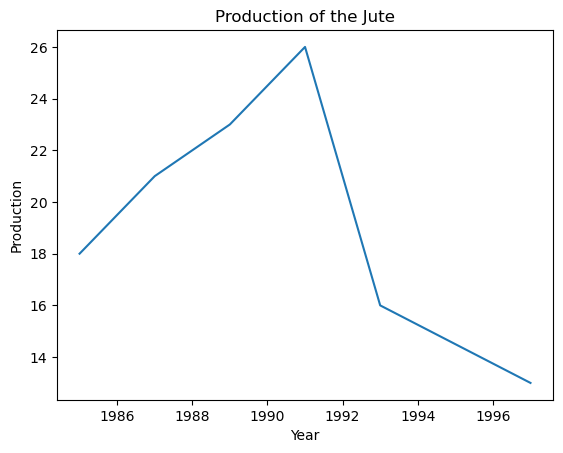

In [23]:
plt.plot(x, y)
plt.xlabel('Year')
plt.ylabel('Production')
plt.title('Production of the Jute')
plt.show()

For `y = a + bx`

In [24]:
# Calculate sums
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x * x)

# Calculate coefficients a and b
lin_b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
lin_a = (sum_y - lin_b * sum_x) / n

# Create a DataFrame
lin_data = {
    'x': x,
    'y': y,
    'xy': x * y,
    'x2': x * x,
    'pred_y': lin_a + lin_b * x,
    'error': abs(y - (lin_a + lin_b * x))
}
lin_df = pd.DataFrame(lin_data)

print(f"Sum of x: {sum_x}")
print(f"Sum of y: {sum_y}")
print(f"Sum of xy: {sum_xy}")
print(f"Sum of x^2: {sum_x2}")
print(f"Value of a: {lin_a}")
print(f"Value of b: {lin_b}")
print(f"Average error: {np.mean(lin_df['error'])}")
print(f"RMS error: {np.sqrt(np.mean(lin_df['error']**2))}")
print("For Year 2003, the production of Jute is: ", lin_a + lin_b * 2003)
lin_df

Sum of x: 11942
Sum of y: 117
Sum of xy: 232819
Sum of x^2: 23768654
Value of a: 1085.75
Value of b: -0.5357142857142857
Average error: 3.2142857142857415
RMS error: 3.8016287236369104
For Year 2003, the production of Jute is:  12.71428571428578


,x,y,xy,x2,pred_y,error
0,1985,18,35730,3940225,22.357143,4.357143
1,1987,21,41727,3948169,21.285714,0.285714
2,1989,23,45747,3956121,20.214286,2.785714
3,1991,26,51766,3964081,19.142857,6.857143
4,1993,16,31888,3972049,18.071429,2.071429
5,1997,13,25961,3988009,15.928571,2.928571


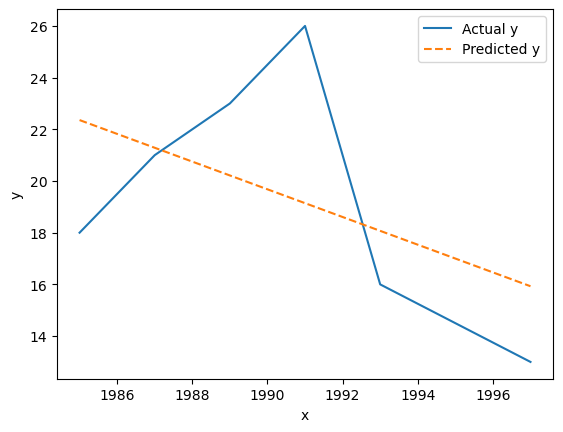

In [25]:
plt.plot(x, y, label='Actual y')
plt.plot(x, lin_a + lin_b * x, label='Predicted y', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

For `y = a + bx + cx2`

In [ ]:
# Calculate sums
sum_x3 = np.sum(x**3)
sum_x4 = np.sum(x**4)
sum_x2y = np.sum(x**2 * y)

# Create the matrices for the normal equations
A = np.array([
    [n, sum_x, sum_x2],
    [sum_x, sum_x2, sum_x3],
    [sum_x2, sum_x3, sum_x4]
])

B = np.array([sum_y, sum_xy, sum_x2y])

# Solve the normal equations to find a, b, and c
coefficients = np.linalg.solve(A, B)
a, b, c = coefficients


# Create a DataFrame
data = {
    'x': x,
    'y': y,rms_error
    'xy': x * y,
    'x2': x * x,
    'x3': x**3,
    'x4': x**4,
    'x2y': x**2 * y,
    'pred_y': a + b * x + c * x**2,
    'error': abs(y - (a + b * x + c * x**2))
}
df = pd.DataFrame(data)

print(f"Sum of x: {sum_x}")
print(f"Sum of y: {sum_y}")
print(f"Sum of xy: {sum_xy}")
print(f"Sum of x^2y: {sum_x2y}")
print(f"Sum of x^2: {sum_x2}")
print(f"Sum of x^3: {sum_x3}")
print(f"Sum of x^4: {sum_x4}")
print(f"Average error: {np.mean(df['error'])}")
print(f"RMS error: {np.sqrt(np.mean(df['error']**2))}")

print(f"Value of a: {a}")
print(f"Value of b: {b}")
print(f"Value of c: {c}")
print("For Year 2003, the production of Jute is: ", a + b * 2003 + c * 2003**2)
df

Sum of x: 11942
Sum of y: 117
Sum of xy: 232819
Sum of x^2y: 463289389
Sum of x^2: 23768654
Sum of x^3: 47307915998
Sum of x^4: 94159632086870
Average error: 1.7143068257331227
RMS error: 2.4102953809578374
Value of a: -777538.6189186735
Value of b: 781.6114596892157
Value of c: -0.19642068659405668
For Year 2003, the production of Jute is:  -12.42756270908285


,x,y,xy,x2,x3,x4,x2y,pred_y,error
0,1985,18,35730,3940225,7821346625,15525373050625,70924050,18.428729,0.428729
1,1987,21,41727,3948169,7845011803,15588038452561,82911549,21.285714,0.285714
2,1989,23,45747,3956121,7868724669,15650893366641,90990783,22.571334,0.428666
3,1991,26,51766,3964081,7892485271,15713938174561,103066106,22.285588,3.714412
4,1993,16,31888,3972049,7916293657,15777173258401,63552784,20.428477,4.428477
5,1997,13,25961,3988009,7964053973,15904215784081,51844117,12.000157,0.999843


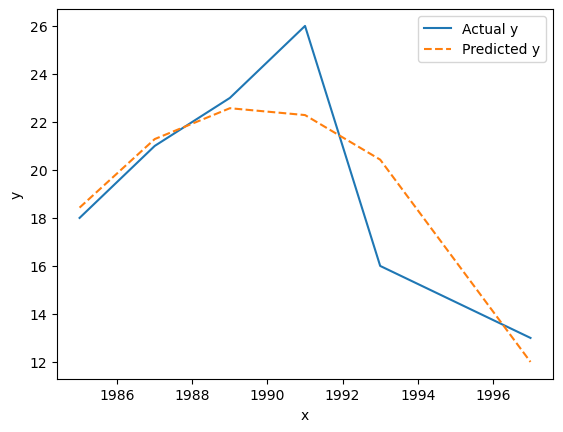

In [27]:
plt.plot(x, y, label='Actual y')
plt.plot(x, a + b * x + c * x**2, label='Predicted y', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

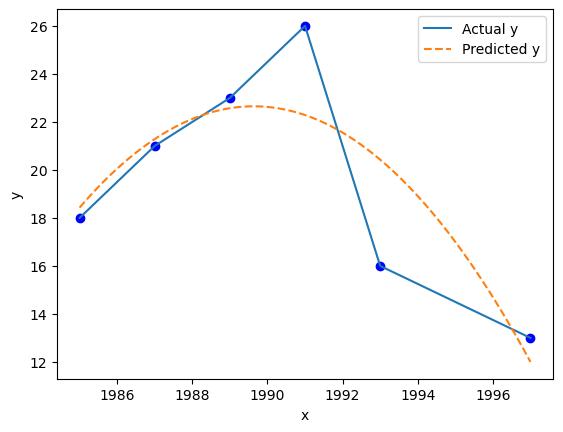

In [28]:
plt.plot(x, y, label='Actual y')
plt.scatter(x, y,color='blue')
large_x = np.linspace(min(x), max(x), 100)
large_y = a + b * large_x + c * large_x**2
plt.plot(large_x, large_y, label='Predicted y', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()